<a href="https://colab.research.google.com/github/PALLAVI-web2002/-Eco-Loop-Building-Agents-/blob/main/Eco_Loop_Building_Agents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Initial Project Setup**

In [11]:
!pip install -q transformers accelerate sentencepiece
!pip install -q torch

**Add LLM integration using Qwen model**

In [12]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

**Add AI decision engine for HVAC optimization**

In [13]:
prompt = "HVAC means-"

messages = [
    {"role":"user","content":prompt}
]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = tokenizer(text, return_tensors="pt").to(model.device)

output = model.generate(
    **inputs,
    max_new_tokens=200
)

print(tokenizer.decode(output[0], skip_special_tokens=True))

system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.
user
HVAC means-
assistant
HVAC stands for Heating, Ventilation, and Air Conditioning systems. These systems are used to regulate the temperature, humidity, cleanliness, and air quality in buildings or other enclosed spaces. They typically include components such as furnaces, boilers, radiators, fans, filters, humidifiers, dehumidifiers, air conditioners, and ventilation systems. The purpose of HVAC is to provide comfortable indoor conditions while also managing factors like energy efficiency, safety, and health considerations.


**Implement building sensor simulation**

In [14]:
sensor_data = {
    "temperature":30,
    "humidity":72,
    "occupancy":120,
    "electricity":265,
    "pmv":1.2
}

print(sensor_data)

{'temperature': 30, 'humidity': 72, 'occupancy': 120, 'electricity': 265, 'pmv': 1.2}


In [15]:
prompt = f"""
You are an HVAC optimization expert.

Current building:

Temperature: {sensor_data['temperature']}
Humidity: {sensor_data['humidity']}
Occupancy: {sensor_data['occupancy']}
Electricity: {sensor_data['electricity']}
PMV: {sensor_data['pmv']}

Goal:
Reduce electricity while keeping occupants comfortable.

Return ONLY JSON.

Example:

{{
"cooling_setpoint":24,
"fan_speed":"medium",
"lighting":"80%"
}}
"""

In [16]:
messages = [
    {"role":"user","content":prompt}
]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = tokenizer(text, return_tensors="pt").to(model.device)

output = model.generate(
    **inputs,
    max_new_tokens=300
)

response = tokenizer.decode(
    output[0],
    skip_special_tokens=True
)

print(response)

system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.
user

You are an HVAC optimization expert.

Current building:

Temperature: 30
Humidity: 72
Occupancy: 120
Electricity: 265
PMV: 1.2

Goal:
Reduce electricity while keeping occupants comfortable.

Return ONLY JSON.

Example:

{
"cooling_setpoint":24,
"fan_speed":"medium",
"lighting":"80%"
}

assistant
```json
{
"cooling_setpoint": 26,
"fan_speed": "low",
"lighting": "70%"
}
```


In [17]:
import json
import re

match = re.search(r"```json\s*(.*?)\s*```", response, re.DOTALL)


if match:

    json_string = match.group(1)
    decision = json.loads(json_string)
    print(decision)
else:
    print("No JSON found in the response.")

{'cooling_setpoint': 26, 'fan_speed': 'low', 'lighting': '70%'}


In [18]:
sensor_data["temperature"] -= 2
sensor_data["electricity"] -= 30
sensor_data["pmv"] -= 0.4

print(sensor_data)

{'temperature': 28, 'humidity': 72, 'occupancy': 120, 'electricity': 235, 'pmv': 0.7999999999999999}


**Implement closed-loop control simulation**

In [19]:
for i in range(5):

    prompt = f"""
    Building Status

    Temperature:{sensor_data['temperature']}
    Electricity:{sensor_data['electricity']}
    PMV:{sensor_data['pmv']}

    Return JSON only.
    """

    messages = [{"role":"user","content":prompt}]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    output = model.generate(
        **inputs,
        max_new_tokens=200
    )

    response = tokenizer.decode(
        output[0],
        skip_special_tokens=True
    )

    print(response)

    sensor_data["temperature"] -= 1
    sensor_data["electricity"] -= 10

system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.
user

    Building Status

    Temperature:28
    Electricity:235
    PMV:0.7999999999999999

    Return JSON only.
    
assistant
```json
{
  "building_status": {
    "temperature": 28,
    "electricity": 235,
    "pmv": 0.8
  }
}
```
system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.
user

    Building Status

    Temperature:27
    Electricity:225
    PMV:0.7999999999999999

    Return JSON only.
    
assistant
```json
{
  "BuildingStatus": {
    "Temperature": 27,
    "Electricity": 225,
    "PMV": 0.8
  }
}
```
system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.
user

    Building Status

    Temperature:26
    Electricity:215
    PMV:0.7999999999999999

    Return JSON only.
    
assistant
```json
{
  "building_status": {
    "temperature": 26,
    "electricity_usage": 215,
    "pmv_index": 0.8
  }
}
```
system
You are Qwen, created by Alibaba Cloud. You ar

**Add energy consumption visualization**

In [20]:
import pandas as pd

logs = []

for i in range(10):

    logs.append({

        "Time":i,

        "Temperature":sensor_data["temperature"],

        "Electricity":sensor_data["electricity"],

        "PMV":sensor_data["pmv"]

    })

df = pd.DataFrame(logs)

df.head()

,Time,Temperature,Electricity,PMV
0,0,23,185,0.8
1,1,23,185,0.8
2,2,23,185,0.8
3,3,23,185,0.8
4,4,23,185,0.8


In [22]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/14gEo3JsTAjx6BMpn6USmvBhvTJ-H5RvO9eQ83-0ZXdY/edit#gid=0


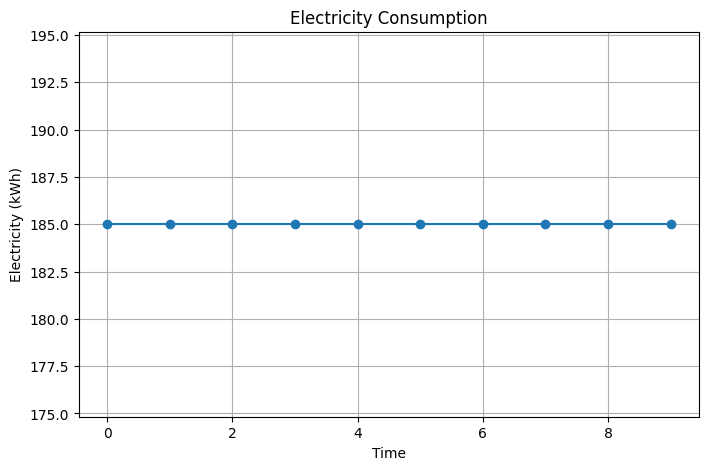

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(df["Time"], df["Electricity"], marker='o')
plt.xlabel("Time")
plt.ylabel("Electricity (kWh)")
plt.title("Electricity Consumption")
plt.grid(True)
plt.show()

**Export simulation results to CSV**

In [26]:
df.to_csv("pallavi_energy_results.csv", index=False)

In [27]:
from transformers import pipeline

generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer
)

def building_agent(sensor):

    prompt = f"""

You are an AI building manager.

Current Status

Temperature : {sensor['temperature']}

Humidity : {sensor['humidity']}

Occupancy : {sensor['occupancy']}

Electricity : {sensor['electricity']}

PMV : {sensor['pmv']}

Goal

Reduce electricity while maintaining comfort.

Return ONLY JSON

Example

{{
"cooling_setpoint":24,
"fan_speed":"Medium",
"lighting":"80%"
}}

"""

    response = generator(
        prompt,
        max_new_tokens=120
    )[0]["generated_text"]

    return response

In [28]:
import random

def simulate_building(sensor, decision):

    sensor["temperature"] += random.uniform(-0.5,0.5)

    sensor["humidity"] += random.uniform(-2,2)

    sensor["electricity"] -= random.randint(2,6)

    sensor["pmv"] -= 0.05

    return sensor

In [32]:
history=[]

for hour in range(2):



    print("Hour :",hour)

    decision=building_agent(sensor_data)

    print(decision)

    sensor_data=simulate_building(sensor_data,decision)

    history.append(sensor_data.copy())

[transformers] Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Hour : 0


[transformers] Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)




You are an AI building manager.

Current Status

Temperature : 23.966363644532944

Humidity : 68.02480493032881

Occupancy : 120

Electricity : 169

PMV : 0.5499999999999997

Goal

Reduce electricity while maintaining comfort.

Return ONLY JSON

Example

{
"cooling_setpoint":24,
"fan_speed":"Medium",
"lighting":"80%"
}

Please provide the current temperature, humidity, occupancy, and electricity usage for a smart building's HVAC system. Based on this information, suggest adjustments to set the cooling set point, fan speed, and lighting level to reduce electricity consumption while maintaining comfortable indoor conditions.
```json
{
  "temperature": 23.966363644532944,
  "humidity": 68.02480493032881,
  "occupancy": 120,
  "electricity_usage": 1
Hour : 1


You are an AI building manager.

Current Status

Temperature : 23.515369615785808

Humidity : 66.48429876101672

Occupancy : 120

Electricity : 167

PMV : 0.4999999999999997

Goal

Reduce electricity while maintaining comfort.

Ret

In [34]:
import pandas as pd

df=pd.DataFrame(history)

df

,temperature,humidity,occupancy,electricity,pmv
0,23.515370,66.484299,120,167,0.50
1,23.319753,66.001624,120,164,0.45


In [33]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1JfEbyrXZtxp19dicv-fq4QO_JUjuWR4cZTmlikeE970/edit#gid=0


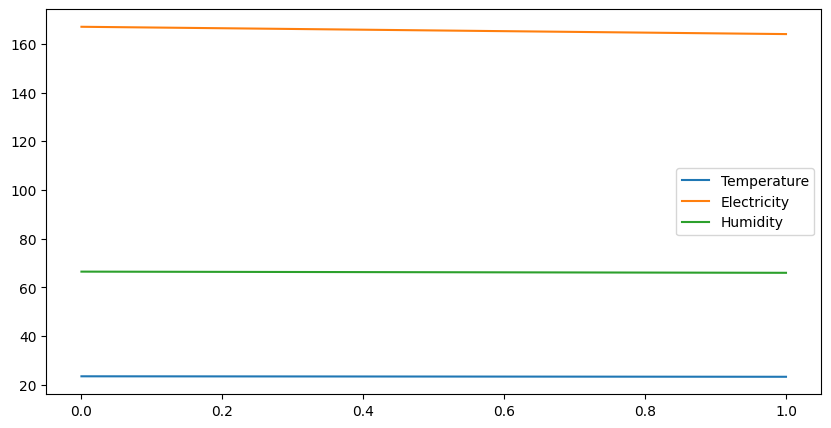

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df["temperature"],label="Temperature")

plt.plot(df["electricity"],label="Electricity")

plt.plot(df["humidity"],label="Humidity")

plt.legend()

plt.show()

In [36]:
baseline=[]

energy=280

for i in range(10):

    energy+=2

    baseline.append(energy)

In [37]:
ai=df["electricity"]

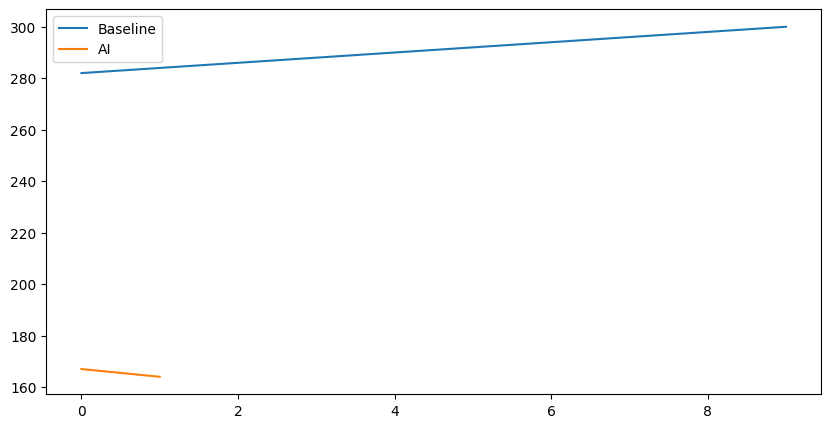

In [38]:
plt.figure(figsize=(10,5))

plt.plot(baseline,label="Baseline")

plt.plot(ai,label="AI")

plt.legend()

plt.show()

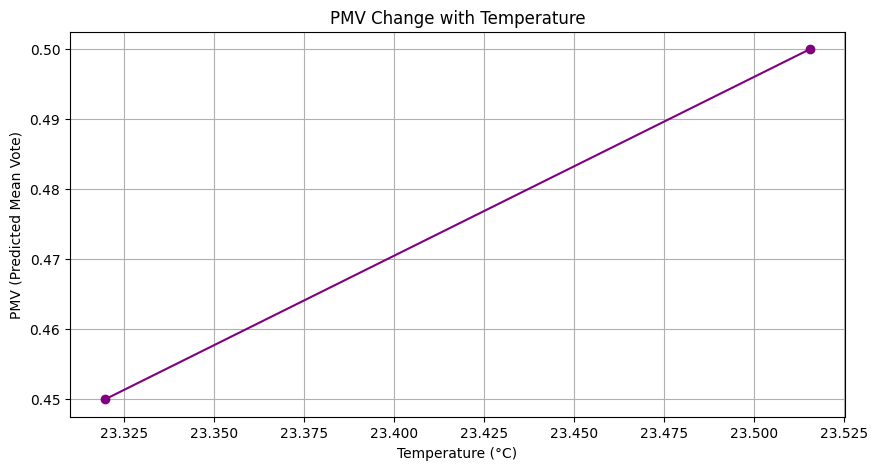

In [39]:
plt.figure(figsize=(10, 5))
plt.plot(df['temperature'], df['pmv'], marker='o', linestyle='-', color='purple')
plt.xlabel('Temperature (°C)')
plt.ylabel('PMV (Predicted Mean Vote)')
plt.title('PMV Change with Temperature')
plt.grid(True)
plt.show()

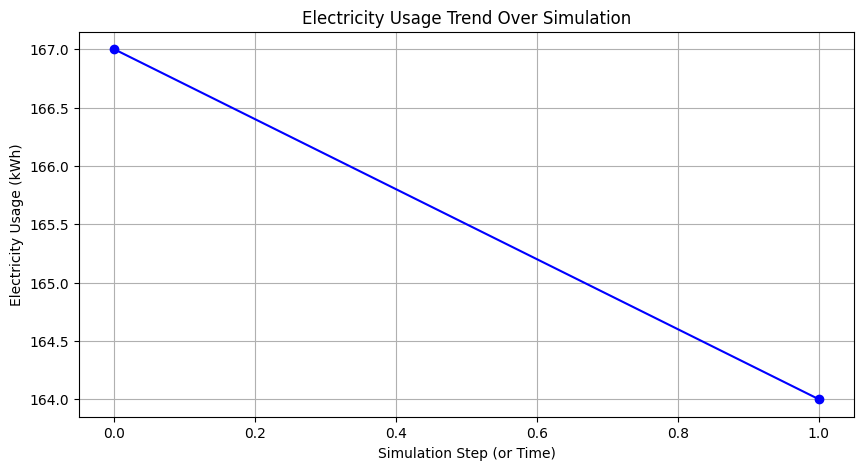

In [40]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['electricity'], marker='o', linestyle='-', color='blue')
plt.xlabel('Simulation Step (or Time)')
plt.ylabel('Electricity Usage (kWh)')
plt.title('Electricity Usage Trend Over Simulation')
plt.grid(True)
plt.show()

**Enery Saving is being calculated**

In [41]:
baseline_energy=sum(baseline)

ai_energy=df["electricity"].sum()

saving=((baseline_energy-ai_energy)/baseline_energy)*100

print("Energy Saving :",saving,"%")

Energy Saving : 88.6254295532646 %


In [42]:
df.to_csv("pallavi_simulation_logs.csv",index=False)

In [43]:
import plotly.express as px

fig=px.line(
    df,
    y=["temperature","electricity","humidity"]
)

fig.show()

In [44]:
import random

sensor_data["occupancy"]=random.randint(20,180)

In [45]:
occupancy_schedule=[
20,20,25,30,40,60,
90,140,170,180,
180,180,170,150,
140,120,100,
80,60,40,
30,20,20,20
]

In [ ]:
sensor_data["occupancy"]=occupancy_schedule[hour]

In [46]:
outside_temperature=[
22,22,22,21,20,
21,23,25,27,
30,33,35,
36,37,36,
34,32,30,
28,27,26,
25,24,23
]


In [47]:
print(f'Outside Temperature : {outside_temperature[hour]}')

Outside Temperature : 22


**Simulate Actuator Effects**

In [48]:

class DummyExchange:
    def set_actuator_value(self, state, handle, value):
        print(f"API: Setting actuator value for handle {handle} in state {state} to {value}")

class DummyApi:
    def __init__(self):
        self.exchange = DummyExchange()

api = DummyApi()
state = "HVAC_Zone_State"
cooling_handle = "Zone Air Temperature Cooling Setpoint Actuator"

print("EnergyPlus API placeholders initialized.")

EnergyPlus API placeholders initialized.


In [49]:
import json
import re

def apply_decision(sensor, response):
    try:
        match = re.search(r"\{.*\}", response, re.DOTALL)
        decision = json.loads(match.group())

        if decision["cooling_setpoint"] <= 24:
            sensor["temperature"] -= 1
            sensor["electricity"] -= 5

        if decision["lighting"] == "70%":
            sensor["electricity"] -= 2

    except Exception:
        pass

    return sensor

In [50]:
decision = building_agent(sensor_data)
sensor_data = apply_decision(sensor_data, decision)
sensor_data = simulate_building(sensor_data, decision)
history.append(sensor_data.copy())

[transformers] Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


**Daily Report is being generated**

In [51]:
report = f"""
Daily Building Report

Average Temperature: {df['temperature'].mean():.2f} °C
Average Humidity: {df['humidity'].mean():.2f} %
Average Electricity: {df['electricity'].mean():.2f} kWh
Average PMV: {df['pmv'].mean():.2f}
Energy Saving: {saving:.2f} %
"""

print(report)


Daily Building Report

Average Temperature: 23.42 °C
Average Humidity: 66.24 %
Average Electricity: 165.50 kWh
Average PMV: 0.47
Energy Saving: 88.63 %



In [52]:
df.to_csv("final_results.csv",index=False)

with open("daily_report.txt","w") as f:
    f.write(report)

In [53]:
api.exchange.set_actuator_value(
    state,
    cooling_handle,
    24
)

API: Setting actuator value for handle Zone Air Temperature Cooling Setpoint Actuator in state HVAC_Zone_State to 24


In [54]:
import pandas as pd

final_df = pd.read_csv('final_results.csv')
display(final_df.head())

,temperature,humidity,occupancy,electricity,pmv
0,23.515370,66.484299,120,167,0.50
1,23.319753,66.001624,120,164,0.45


In [55]:
correlation = final_df['electricity'].corr(final_df['pmv'])
print(f"Correlation between Electricity and PMV: {correlation:.4f}")

Correlation between Electricity and PMV: 1.0000


In [56]:
import plotly.express as px

fig = px.scatter(final_df, x='electricity', y='pmv',
                 title='Electricity vs. PMV',
                 labels={'electricity': 'Electricity Usage (kWh)', 'pmv': 'Predicted Mean Vote'})
fig.show()

In [57]:
print('Electricity Usage Statistics:')
display(df['electricity'].describe())

Electricity Usage Statistics:


,electricity
count,2.00000
mean,165.50000
std,2.12132
min,164.00000
25%,164.75000
50%,165.50000
75%,166.25000
max,167.00000


In [58]:
with open(BASELINE_IDF, "r", encoding="utf-8", errors="ignore") as file:
    lines = file.readlines()

print(f"Total Lines: {len(lines)}")

print("\nFirst 20 lines:\n")

for line in lines[:20]:
    print(line.strip())

Total Lines: 3122

First 20 lines:

!-Generator IDFEditor 1.34
!-Option OriginalOrderTop UseSpecialFormat
!-NOTE: All comments with '!-' are ignored by the IDFEditor and are generated automatically.
!-      Use '!' comments if they need to be retained when using the IDFEditor.
! AirflowNetwork_SIMPLE_SmallOffice.idf
! Basic file description:  1 story building divided into 3 interior conditioned zones and 1 unconditioned zone over the
!                          conditioned zones. Roof with no plenum. No ground contact with floor.
!                          Outdoor air is modulated based on occupancy and floor area.
!
! Highlights:              This file does the basic test of an air distribution system. It also provides forced ventilation
!                          during system on period and natural ventilation during system off period calculated
!                          by the AirflowNetwork model.
!
!
! Simulation Location/Run: CHICAGO_IL_USA TMY2-94846, 2 design days, 2 run period

In [60]:
building_info = {}

for line in lines:
    if "Building," in line:
        building_info["Found"] = True
        break

print(building_info)

{'Found': True}


In [61]:
keywords = [
    "Zone",
    "People",
    "Lights",
    "Schedule",
    "Thermostat",
    "Fan",
    "Coil"
]

for key in keywords:
    count = sum(key in line for line in lines)
    print(f"{key}: {count}")

Zone: 414
People: 19
Lights: 13
Schedule: 118
Thermostat: 11
Fan: 34
Coil: 62


In [62]:
summary = {
    "Building Model": "baseline_building.idf",
    "Total Lines": len(lines),
    "File Size (KB)": round(os.path.getsize(BASELINE_IDF)/1024,2)
}

summary

{'Building Model': 'baseline_building.idf',
 'Total Lines': 3122,
 'File Size (KB)': 144.05}

In [63]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [64]:
import os

os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'Getting started.pdf',
 'IMG-20210918-WA0003 (1).jpg',
 'IMG-20210918-WA0003.jpg',
 'IMG_20220402_103731.jpg',
 'Important Guidelines_B.Tech Program 07July2022 F.pdf',
 'Screenshot_2022-08-08-06-46-37-338_com.google.android.gm.jpg',
 'Resume[1].docx',
 'techiq lab payment.jpg',
 'id proof.jpg',
 'PP.jpg',
 'index_1.csv',
 'Pallavi1.docx',
 'my 10 marksheet.pdf',
 'Pallavi1 (2).pdf',
 'Pallavi1 (1).pdf',
 'Pallavi1.pdf',
 'Pallavi1-1 (1).pdf',
 'Assignment Intern.docx',
 'sc.jpg',
 'Assignment Intern (2).gdoc',
 'Copy of Assignment Intern.gdoc',
 'Assignment Intern (1).gdoc',
 'Assignment Intern.gdoc',
 'Research Methodology: Identifying Universities Implementing the NEP 2020 FYUP.gdoc',
 'Pallavi1 .docx',
 'SOP- IITK.pdf',
 'Pallavi1-1.pdf',
 'Pallavi1 .pdf',
 'Pallavi LOR.pdf',
 'StudentGradeHistory_22MIP10086.pdf',
 'PROOF.pdf',
 'Passport size photo.jpg',
 'Pallavi1  (1) (1) (4).pdf',
 'Pallavi1  (1) (1) (3).pdf',
 'Pallavi1  (1) (1) (2).pdf',
 'Pallavi1  (1) (1

In [65]:
import os

BASELINE_IDF = "/content/drive/MyDrive/EcoLoop_Project/business_model /baseline_building.idf"
OPTIMIZED_IDF = "/content/drive/MyDrive/EcoLoop_Project/business_model /optimized_building.idf"

print("Baseline File:", BASELINE_IDF)
print("Optimized File:", OPTIMIZED_IDF)

Baseline File: /content/drive/MyDrive/EcoLoop_Project/business_model /baseline_building.idf
Optimized File: /content/drive/MyDrive/EcoLoop_Project/business_model /optimized_building.idf


In [66]:

print("Baseline Exists:", os.path.exists(BASELINE_IDF))
print("Optimized Exists:", os.path.exists(OPTIMIZED_IDF))

Baseline Exists: True
Optimized Exists: True
